<a href="https://colab.research.google.com/github/viktoruebelhart/pos_facens/blob/main/Aula_2_amostragem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Métodos de Amostragem em Python**

Fonte: https://www.meccanismocomplesso.org/en/sampling-methods-in-python/

**- O que é amostragem?**

A amostragem é o processo de selecionar um subconjunto representativo de uma população maior para conduzir uma análise estatística ou pesquisa. Em vez de coletar dados de toda a população vamos selecionar uma amostra de indivíduos ou itens que refletem as características da população como um todo.

A amostragem é fundamental em estatísticas porque permite fazer inferências sobre a população maior sem a necessidade de coletar dados de todos os seus membros. No entanto, é importante que a amostra seja selecionada seja representativa para evitar vieses e garantir que as conclusões sejam válidas para toda a população.



**- Para garantir que uma amostra seja representativa da população, considere os seguintes pontos:**

*Método de Amostragem*: A amostra deve utilizar metodologia que permita a representatividade das características da população, utilizando métodos aleatórios, ou não aleatórios.

*Tamanho da Amostra*: A amostra deve ser grande o suficiente para capturar a variabilidade presente na população.

*Representatividade das Características*: A amostra deve refletir as principais características da população, como proporções de gênero ou outras variáveis demográficas importantes, por exemplo.

*Avaliação Estatística*: Usar análises estatísticas para avaliar se a amostra é representativa da população, comparando características demográficas, por exemplo, ou outras variáveis-chave.


#**Implementando Métodos de Amostragem em Python: Definição de uma População de Teste**

Para implementar métodos de amostragem em Python, primeiro precisamos criar uma população que simule uma real. Isso envolve gerar valores aleatórios que descrevam as características de cada elemento da população. Embora a população real deva ser grande, usaremos 100 indivíduos para simplificar o exemplo.


In [ ]:
import numpy as np
import pandas as pd

# Criação de uma população amostral usando distribuição normal
population = pd.DataFrame({
    'ID': range(1, 1000001),  # Identificadores únicos para os indivíduos
    'Age': np.random.normal(35, 10, size=1000000).astype(int),  # Idade com média 35 anos e desvio padrão de 10 anos
    'Gender': np.random.choice(['Male', 'Female'], size=1000000),  # Gênero aleatório
    'Income': np.random.randint(5000, 25000, size=1000000)  # Renda entre 5000 e 25000
})

population

,ID,Age,Gender,Income
0,1,12,Female,23780
1,2,47,Male,8666
2,3,30,Female,19572
3,4,47,Male,19750
4,5,26,Male,24512
...,...,...,...,...
999995,999996,48,Female,22135
999996,999997,31,Male,5628
999997,999998,28,Male,6303
999998,999999,21,Male,8746


A variável "population" é um DataFrame que representa uma população fictícia de um milhão de indivíduos, cada um com um identificador único, uma idade aleatória, com dados gerados a partir de uma distribuição normal, gênero aleatório e uma renda aleatória. Este é um exemplo resumido de uma população que pode ser usada para análise estatística ou simulação. Ao executar o código anterior, você obterá um DataFrame com 100 indivíduos diferentes, distribuídos uniformemente entre as idades possíveis (entre 18 e 70 anos) e com valores de renda distribuídos normalmente. Os valores variarão a cada execução do código.

**Visualizando o histograma**

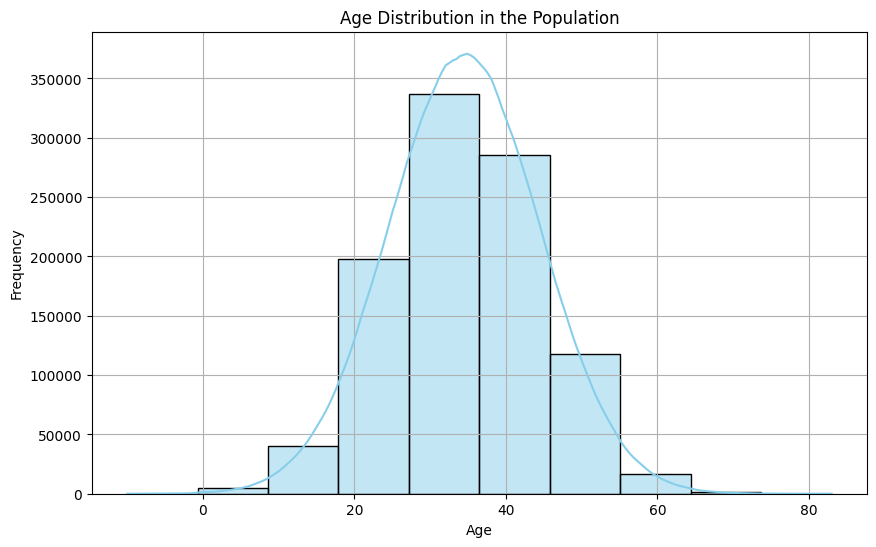

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizando o histogram da variável "Age" (idade)
plt.figure(figsize=(10, 6))
sns.histplot(population['Age'], bins=10, kde=True, color='skyblue')
plt.title('Age Distribution in the Population')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

A variável "Income", não foi gerada a partir de uma distribuição normal, veja a diferença no histograma:

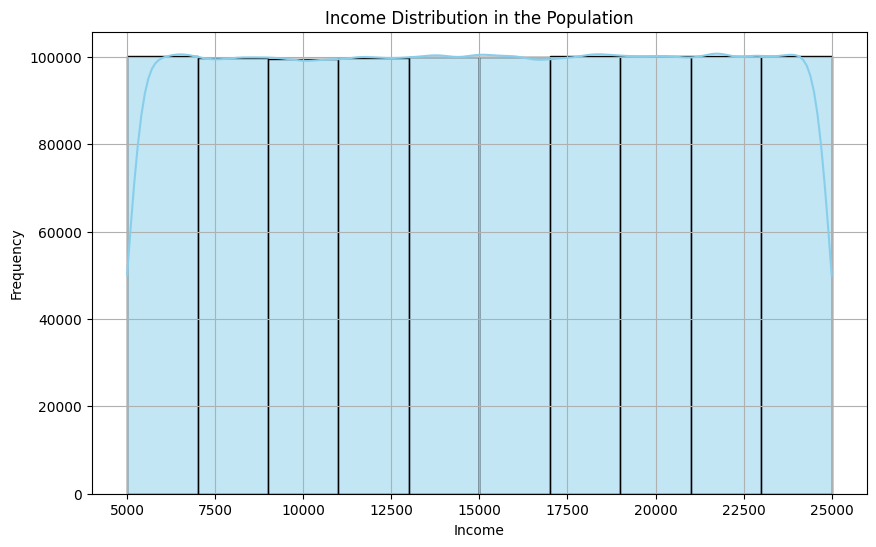

In [ ]:
# Visualizando o histogram da variável "Income" (renda)
plt.figure(figsize=(10, 6))
sns.histplot(population['Income'], bins=10, kde=True, color='skyblue')
plt.title('Income Distribution in the Population')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

**Realizando a análise estatística descritiva**

In [ ]:
from scipy.stats import skew, kurtosis

# Filtrando apenas colunas numéricas
numeric_df = population.select_dtypes(include=[np.number])

# Calculando estatísticas básicas
statistics_summary = numeric_df.describe().T

# Calculando estatísticas adicionais
statistics_summary['median'] = numeric_df.median()
statistics_summary['mode'] = numeric_df.mode().iloc[0]
statistics_summary['range'] = numeric_df.max() - numeric_df.min()
statistics_summary['cv'] = statistics_summary['std'] / statistics_summary['mean']  # Coeficiente de variação
statistics_summary['skewness'] = numeric_df.apply(lambda x: skew(x.dropna()))
statistics_summary['kurtosis'] = numeric_df.apply(lambda x: kurtosis(x.dropna()))
statistics_summary['sem'] = numeric_df.sem()  # Erro padrão da média

# Calculando quartis e intervalo interquartil
quartiles = numeric_df.quantile([0.25, 0.75])
statistics_summary['Q1'] = quartiles.loc[0.25]
statistics_summary['Q3'] = quartiles.loc[0.75]
statistics_summary['IQR'] = statistics_summary['Q3'] - statistics_summary['Q1']

# Visualizando o resumo das estatísticas
statistics_summary = statistics_summary[['count', 'mean', 'std', 'median', 'mode', 'min', 'max', 'range', 'Q1', 'Q3', 'IQR', 'cv', 'skewness', 'kurtosis', 'sem']]

# Formatando todas as colunas para exibir duas casas decimais
statistics_summary = statistics_summary.applymap(lambda x: f"{x:.2f}")

# Exibindo o resumo das estatísticas
statistics_summary

/tmp/ipykernel_5154/707754850.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  statistics_summary = statistics_summary.applymap(lambda x: f"{x:.2f}")


,count,mean,std,median,mode,min,max,range,Q1,Q3,IQR,cv,skewness,kurtosis,sem
ID,1000000.00,500000.50,288675.28,500000.50,1.00,1.00,1000000.00,999999.00,250000.75,750000.25,499999.50,0.58,-0.00,-1.20,288.68
Age,1000000.00,34.50,10.00,35.00,35.00,-10.00,83.00,93.00,28.00,41.00,13.00,0.29,-0.00,-0.01,0.01
Income,1000000.00,15009.16,5775.41,15017.00,13629.00,5000.00,24999.00,19999.00,10006.00,20012.00,10006.00,0.38,-0.00,-1.20,5.78


#**Métodos de Amostragem**

Os métodos de amostragem são projetados para garantir que a amostra seja representativa da população de interesse, e a escolha do método depende da natureza da pesquisa,  recursos disponíveis e outros fatores relevantes.

Existem vários métodos de amostragem, e a escolha do método depende do objetivo do estudo e das características da população. Iremos utilizar os métodos de amostragem:

- Amostragem aleatória simples
- Amostragem sistemática
- Amostragem estratificada
- Amostragem por conglomerados
- Amostragem por cotas
- Amostragem por conveniência

##**Amostragem Aleatória Simples**

A amostragem aleatória simples é um dos métodos de amostragem mais simples e fundamentais em estatística. Consiste em selecionar aleatoriamente uma amostra de indivíduos da população sem qualquer tipo de estratificação ou subdivisão. Cada indivíduo na população tem a mesma probabilidade de ser selecionado para fazer parte da amostra. Esse método é amplamente utilizado porque é fácil de implementar e fornece uma estimativa não tendenciosa das características da população.

In [ ]:
# Amostragem Aleatória Simples
def amostragem_aleatoria_simples(population, n):
    """
    Seleciona aleatoriamente uma amostra de indivíduos da população.

    Parâmetros:
    populacao (DataFrame): A população da qual a amostra será retirada.
    n (int): O número de indivíduos a serem selecionados na amostra.

    Retorna:
    DataFrame: Uma amostra aleatória de n indivíduos da população.
    """
    return population.sample(n)

# Exemplo de uso da amostragem aleatória simples para selecionar 10 indivíduos
# Aqui 'populacao' é o DataFrame que contém os dados da população
amostra_aleatoria = amostragem_aleatoria_simples(population, 1000)
print("Amostragem Aleatória Simples:")
print(amostra_aleatoria)

Amostragem Aleatória Simples:
            ID  Age  Gender  Income
573811  573812   37    Male   22851
293245  293246   34    Male    8840
616942  616943   40  Female   16378
193140  193141   33  Female    7484
418590  418591   32    Male   21329
...        ...  ...     ...     ...
311265  311266   33    Male   19730
155747  155748   25  Female   16048
281690  281691   45  Female   22470
111295  111296   29  Female   21755
932230  932231   26  Female   14695

[1000 rows x 4 columns]


**Verificando os parâmetros estatísticos descritivos:**

In [ ]:
population.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,1000000.0,500000.500000,288675.278933,1.0,250000.75,500000.5,750000.25,1000000.0
Age,1000000.0,34.497224,10.002816,-10.0,28.00,35.0,41.00,83.0
Income,1000000.0,15009.157134,5775.414064,5000.0,10006.00,15017.0,20012.00,24999.0


In [ ]:
amostra_aleatoria.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,1000.0,516642.491,293259.352637,557.0,270736.50,529896.5,774075.00,999608.0
Age,1000.0,34.549,10.098593,2.0,28.00,34.5,42.00,66.0
Income,1000.0,14888.049,5758.525294,5021.0,9767.25,14918.5,19793.75,24977.0


**Visualizando os histogramas juntos**

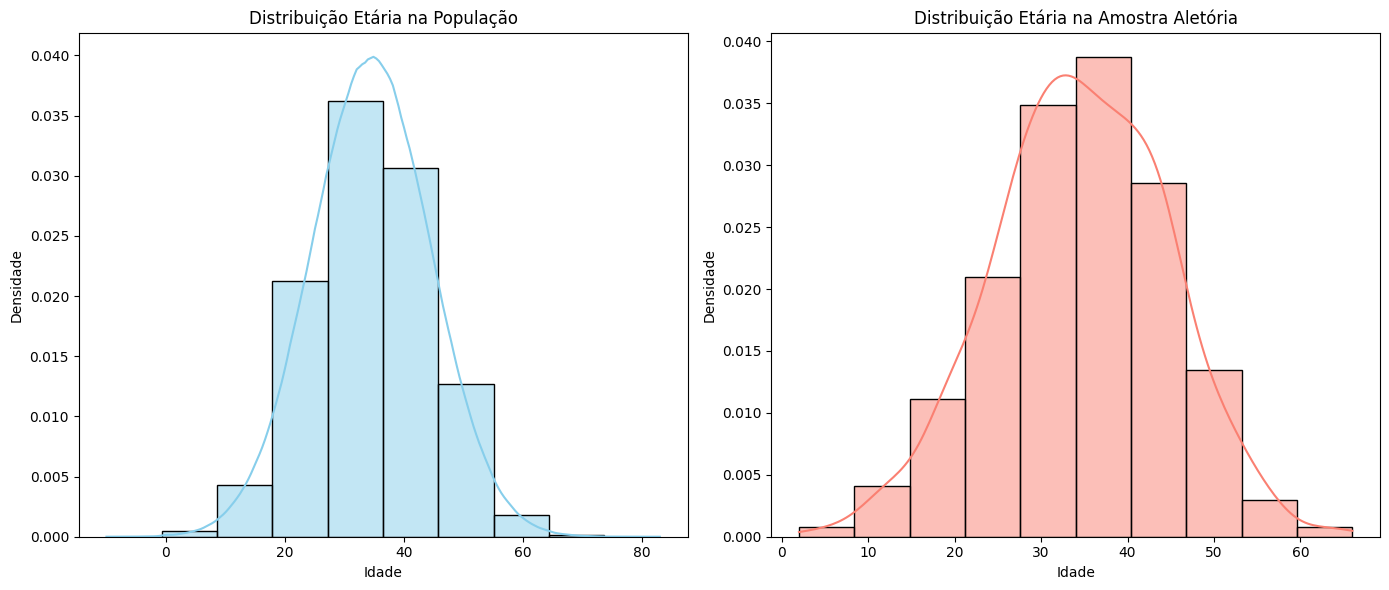

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Supondo que 'population' e 'systematic_sample' sejam seus DataFrames
# e as colunas 'Age' estejam definidas

# Configurações para o tamanho da figura
plt.figure(figsize=(14, 6))

# Plotando o histograma com curva de densidade para a coluna 'Age' do DataFrame 'population'
plt.subplot(1, 2, 1)  # 1 linha, 2 colunas, 1ª posição
sns.histplot(population['Age'], bins=10, kde=True, color='skyblue', edgecolor='black', stat='density')
plt.title('Distribuição Etária na População')
plt.xlabel('Idade')
plt.ylabel('Densidade')

# Plotando o histograma com curva de densidade para a coluna 'Age' do DataFrame 'systematic_sample'
plt.subplot(1, 2, 2)  # 1 linha, 2 colunas, 2ª posição
sns.histplot(amostra_aleatoria['Age'], bins=10, kde=True, color='salmon', edgecolor='black', stat='density')
plt.title('Distribuição Etária na Amostra Aletória')
plt.xlabel('Idade')
plt.ylabel('Densidade')

# Ajustando o layout para evitar sobreposição
plt.tight_layout()

# Exibindo os gráficos
plt.show()

##**Amostragem estratificada**

Técnica de amostragem que divide a população em grupos homogêneos chamados “estratos” e, em seguida, seleciona uma amostra aleatória de cada um desses estratos. Esse método é utilizado quando a população possui heterogeneidade em algumas características-chave e o objetivo é garantir que a amostra reflita com precisão essa heterogeneidade.

Inicialmente, a população é dividida em grupos ou estratos homogêneos com base em uma característica ou variável de interesse. Por exemplo, se estamos estudando a renda dos indivíduos, podemos dividir a população em estratos com base em grupos de renda, como baixa, média e alta. Após definir os estratos, uma amostra aleatória é selecionada de cada um deles. É importante que a seleção das amostras dentro de cada estrato ocorra de forma aleatória, para garantir a representatividade da amostra geral. Uma vez que as amostras de cada estrato são selecionadas, elas são combinadas para formar a amostra estratificada geral.

A amostragem estratificada é útil quando a população apresenta variação significativa nas características de interesse e quando se deseja garantir que a amostra reflita com precisão essa diversidade. Ela é particularmente eficaz na redução da variância estimada e na melhoria da precisão das estimativas estatísticas em comparação com a amostragem aleatória simples, especialmente quando os estratos são homogêneos internamente, mas heterogêneos entre si.

Por exemplo, se estamos realizando um estudo sobre a satisfação no trabalho dos funcionários de uma empresa, podemos dividir a população em estratos com base no nível de senioridade (por exemplo, novos contratados, funcionários de longa data, gerentes) e, em seguida, selecionar uma amostra aleatória de cada um desses grupos para formar uma amostra estratificada.

No nosso exemplo iremos utilizar a idade como elemento para identificar os estratos.

In [ ]:
import pandas as pd

# Amostragem estratificada pela indade
def stratified_sampling(population, n, stratification):
    """
    Realiza a amostragem estratificada com base na idade.

    Parameters:
    population (DataFrame): O DataFrame contendo a população.
    n (int): O número total de indivíduos a serem selecionados.
    stratification (dict): Um dicionário onde as chaves são as idades (estratos) e os valores são as proporções de amostra para cada estrato.

    Retorna:
    DataFrame: Um DataFrame contendo a amostra estratificada.
    """
    sample = pd.DataFrame()   # DataFrame vazio para armazenar a amostra

    # Itera sobre cada estrato definido na estratificação
    for value, proportion in stratification.items():
        stratum = population[population['Age'] == value]  # Filtra a população pelo estrato atual

        # Verifica se o estrato contém indivíduos
        if stratum.empty:
            print(f"There are no individuals in the population with age {value}.")
            print("Please modify the population or change the age.")
            return sample

        # Verifica se há indivíduos suficientes para a amostra no estrato atual
        if len(stratum) < int(n * proportion):
            print(f"There are not enough individuals in the population with age {value}.")
            return sample
        else:
            # Seleciona uma amostra aleatória do estrato atual
            stratum_sample = stratum.sample(int(n * proportion))
            sample = pd.concat([sample, stratum_sample])  # Concatena a amostra do estrato com a amostra geral

    return sample

# Exemplo de uso da amostragem estratificada por idade para selecionar 10 indivíduos
age_stratification = {20: 0.2, 25: 0.3, 30: 0.2, 35: 0.1, 40: 0.2}  # Proporções para cada estrato de idade
stratified_age_sample = stratified_sampling(population, 100, age_stratification)

print("\nAmostragem Estratificada por Idade:")
print(stratified_age_sample)


Amostragem Estratificada por Idade:
            ID  Age  Gender  Income
190837  190838   20  Female   18975
314626  314627   20    Male   17218
6215      6216   20  Female    8963
618820  618821   20    Male   16945
746555  746556   20  Female   17505
...        ...  ...     ...     ...
664924  664925   40  Female    6960
882124  882125   40  Female    6289
816705  816706   40  Female   10106
879458  879459   40  Female    9580
800018  800019   40    Male    6956

[100 rows x 4 columns]


**Verificando os parâmetros estatísticos descritivos da amostra:**

In [ ]:
population.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,1000000.0,500000.500000,288675.278933,1.0,250000.75,500000.5,750000.25,1000000.0
Age,1000000.0,34.497224,10.002816,-10.0,28.00,35.0,41.00,83.0
Income,1000000.0,15009.157134,5775.414064,5000.0,10006.00,15017.0,20012.00,24999.0


In [ ]:
stratified_age_sample.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,100.0,555622.25,299182.103420,6216.0,272676.0,632265.0,803518.75,996579.0
Age,100.0,29.00,7.035265,20.0,25.0,27.5,35.00,40.0
Income,100.0,14596.59,5606.094799,5260.0,9545.0,14254.0,18903.00,24798.0


**Visualizando os histogramas juntos:**

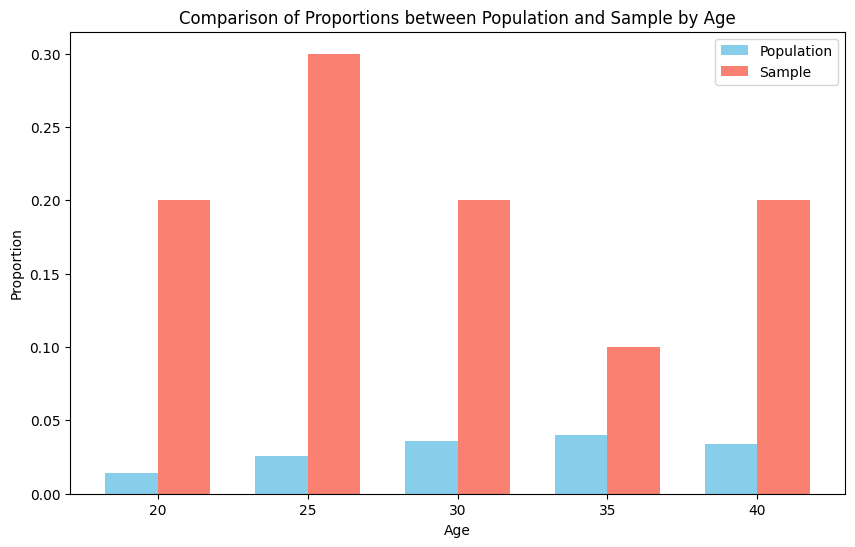

In [ ]:
import matplotlib.pyplot as plt

# Calculate proportions in the population
population_proportions = {age: len(population[population['Age'] == age]) / len(population) for age in age_stratification.keys()}

# Calculate proportions in the sample
sample_proportions = {age: len(stratified_age_sample[stratified_age_sample['Age'] == age]) / len(stratified_age_sample) for age in age_stratification.keys()}

# Ages and proportion values
ages = list(age_stratification.keys())
population_props = list(population_proportions.values())
sample_props = list(sample_proportions.values())

# Bar width
bar_width = 0.35

# Bar positions on the plot
positions = range(len(ages))

# Create the bar plot
plt.figure(figsize=(10, 6))
plt.bar(positions, population_props, bar_width, label='Population', color='skyblue')
plt.bar([p + bar_width for p in positions], sample_props, bar_width, label='Sample', color='salmon')

# Labels and title
plt.xlabel('Age')
plt.ylabel('Proportion')
plt.title('Comparison of Proportions between Population and Sample by Age')
plt.xticks([p + bar_width / 2 for p in positions], ages)
plt.legend()

plt.show()

##**Amostragem Sistemática**

A amostragem sistemática é uma técnica de amostragem na qual indivíduos da população são selecionados em intervalos regulares, utilizando um processo sistemático. Este método envolve dividir a população em uma lista ordenada e selecionar cada k-ésimo elemento dessa lista, onde k é o chamado “intervalo de amostragem”.

O intervalo de amostragem, denotado por k, representa o número de elementos da população entre cada seleção. Por exemplo, se temos uma população de 1000 indivíduos e escolhemos um intervalo de amostragem de 10, selecionaremos cada 10º indivíduo para fazer parte da amostra. A população é ordenada com base em uma característica de interesse. Essa característica pode ser qualquer variável que permita atribuir uma ordem aos indivíduos na população, como um identificador único ou uma característica numérica. Após definir o intervalo de amostragem e ordenar a população, a amostra é selecionada escolhendo cada k-ésimo elemento da lista ordenada. Por exemplo, se o intervalo de amostragem for 10, serão selecionados o primeiro, o décimo primeiro, o vigésimo primeiro, e assim por diante, até que a amostra desejada seja completada.

A amostragem sistemática é frequentemente utilizada quando a população já está ordenada ou quando é difícil obter uma amostra completamente aleatória. Essa técnica é relativamente simples de implementar e pode ser eficiente quando a população é grande e a distribuição dos indivíduos é uniforme. No entanto, é importante observar que a amostragem sistemática pode levar à introdução de viés se a ordem da população seguir um padrão que não represente com precisão a variação na característica de interesse. Portanto, é aconselhável realizar uma análise crítica dos resultados obtidos por meio da amostragem sistemática.

In [ ]:
# Amostragem Sistemática
def systematic_sampling(population, n):
    k = len(population) // n  # Número de indivíduos em cada intervalo
    start = np.random.randint(0, k)  # Ponto de partida aleatório
    sampled_indices = np.arange(start, len(population), step=k)
    return population.iloc[sampled_indices]

# Exemplo de uso da amostragem sistemática para selecionar 100 indivíduos
systematic_sample = systematic_sampling(population, 100)
print("\nAmostragem Sistemática:")
print(systematic_sample)


Amostragem Sistemática:
            ID  Age  Gender  Income
7979      7980   38  Female    7498
17979    17980   53    Male    6908
27979    27980   20  Female    9301
37979    37980   26  Female   20935
47979    47980   44    Male   10760
...        ...  ...     ...     ...
957979  957980   26    Male   11883
967979  967980   40  Female   12211
977979  977980   35    Male   10461
987979  987980   28  Female   14015
997979  997980   44    Male   10318

[100 rows x 4 columns]


Observação:

O valor de 𝑘 é calculado como o número total de indivíduos na população dividido pelo número desejado de amostras 𝑛. No código, o cálculo é feito com a linha:

k = len(population) // n

Aqui, len(population) retorna o número total de indivíduos na população, e n é o número de indivíduos que você deseja na amostra.

O operador // realiza a divisão inteira, ou seja, divide o número total de indivíduos pelo número desejado de amostras e arredonda para baixo, obtendo o intervalo de amostragem.

Por exemplo, se a população tem 1000 indivíduos e você deseja selecionar 15 amostras, o valor de 𝑘 será:

𝑘 = 1000/15 ≈ 66

Então,
𝑘 será 66, indicando que cada 66º indivíduo será selecionado para a amostra, começando a partir de um ponto inicial aleatório.

**Verificando os parâmetros estatísticos descritivos da amostra:**

In [ ]:
population.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,1000000.0,500000.500000,288675.278933,1.0,250000.75,500000.5,750000.25,1000000.0
Age,1000000.0,34.497224,10.002816,-10.0,28.00,35.0,41.00,83.0
Income,1000000.0,15009.157134,5775.414064,5000.0,10006.00,15017.0,20012.00,24999.0


In [ ]:
systematic_sample.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,100.0,502980.00,290114.919759,7980.0,255480.0,502980.0,750480.0,997980.0
Age,100.0,34.88,10.985096,12.0,27.0,35.0,44.0,58.0
Income,100.0,13518.14,5227.787647,5233.0,9285.5,13018.5,17589.5,24917.0


**Visualizando os histogramas juntos:**

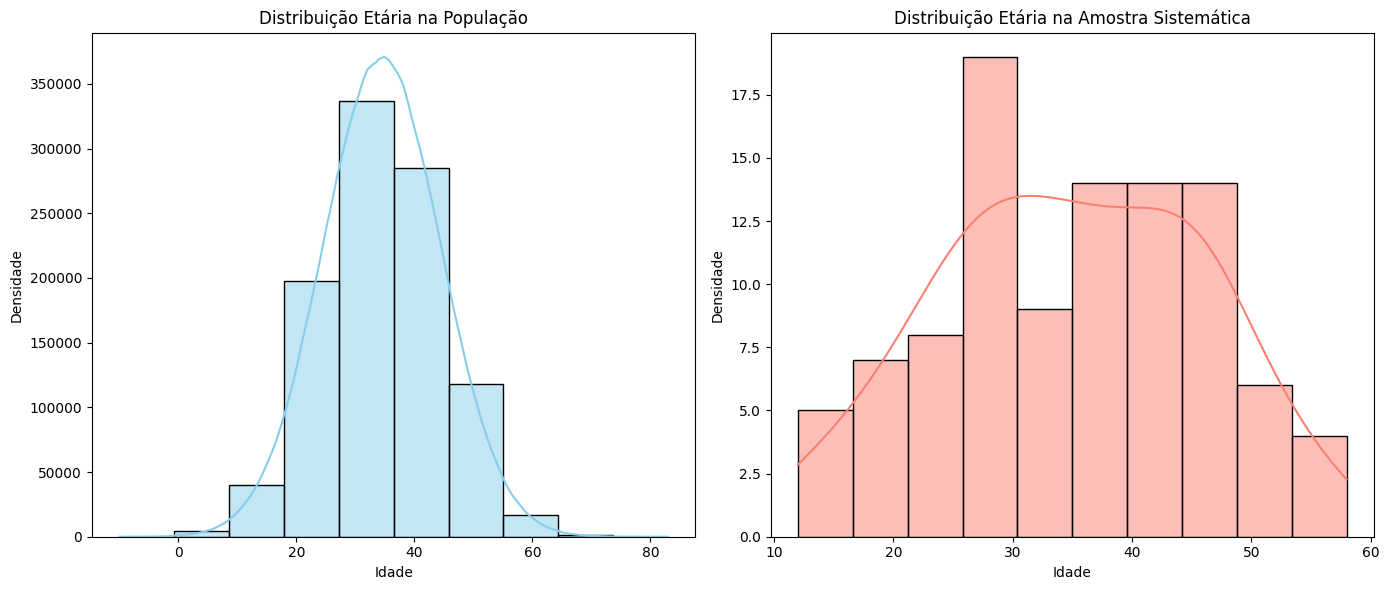

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criar uma figura com dois subgráficos
plt.figure(figsize=(14, 6))

# Primeiro gráfico: Distribuição etária na população
plt.subplot(1, 2, 1)  # (linhas, colunas, índice do gráfico)
sns.histplot(population['Age'], bins=10, kde=True, color='skyblue')
plt.title('Distribuição Etária na População')
plt.xlabel('Idade')
plt.ylabel('Densidade')

# Segundo gráfico: Distribuição etária na amostra
plt.subplot(1, 2, 2)  # (linhas, colunas, índice do gráfico)
sns.histplot(systematic_sample['Age'], bins=10, kde=True, color='salmon')
plt.title('Distribuição Etária na Amostra Sistemática')
plt.xlabel('Idade')
plt.ylabel('Densidade')

plt.tight_layout()
plt.show()

##**Amostragem por Conglomerados**

A amostragem por conglomerados é uma técnica de amostragem na qual a população é dividida em grupos, chamados de “conglomerados”, e um subconjunto desses conglomerados é selecionado aleatoriamente para formar a amostra. Essa técnica é útil quando a população está naturalmente organizada em grupos ou conglomerados e quando não é prático ou possível selecionar individualmente os elementos da população.

Os conglomerados são grupos homogêneos de indivíduos dentro da população. Eles podem ser definidos com base em fatores geográficos, sociais ou outros que refletem a estrutura natural da população. Por exemplo, se estivermos estudando a educação primária em uma determinada área geográfica, os conglomerados poderiam ser as escolas nessa área. Após definir os conglomerados, um subconjunto deles é selecionado aleatoriamente para formar a amostra. Essa seleção é feita usando uma técnica de amostragem aleatória, como a amostragem aleatória simples ou a amostragem sistemática. Uma vez que os conglomerados são selecionados, amostragem adicional pode ser realizada dentro de cada conglomerado para selecionar indivíduos ou elementos específicos a serem incluídos na amostra. Isso pode ser feito usando outras técnicas de amostragem, como a amostragem aleatória simples ou estratificada.

A amostragem por conglomerados é particularmente útil quando a população é grande e dispersa ou quando é difícil selecionar individualmente os elementos da população. Essa técnica permite simplificar o processo de amostragem, focando na seleção de grupos representativos da população em vez de indivíduos. No entanto, é importante ter em mente que a amostragem por conglomerados pode levar a uma precisão menor em comparação com outras técnicas de amostragem, pois os indivíduos dentro de cada conglomerado podem não ser totalmente representativos da população geral. Portanto, é importante avaliar cuidadosamente os trade-offs entre eficiência e precisão ao usar essa técnica de amostragem.

In [ ]:
import numpy as np
import pandas as pd

# Função para realizar a amostragem por conglomerados
def cluster_sampling(population, n, num_clusters):
    """
    Realiza a amostragem por conglomerados na população.

    Parâmetros:
    population (DataFrame): O DataFrame que contém a população.
    n (int): O número de indivíduos desejados na amostra final.
    num_clusters (int): O número de conglomerados em que a população será dividida.

    Retorna:
    DataFrame: Uma amostra com 'n' indivíduos selecionados.
    """
    # Dividir a população em 'num_clusters' conglomerados
    clusters = np.array_split(population, num_clusters)

    # Selecionar aleatoriamente um indivíduo de cada conglomerado
    sampled_clusters = [cluster.sample(1) for cluster in clusters]

    # Concatenar os indivíduos selecionados de todos os conglomerados
    sample = pd.concat(sampled_clusters, axis=0)

    # Retornar os primeiros 'n' indivíduos da amostra
    return sample.head(n)

# Exemplo de uso da amostragem por conglomerados para selecionar 100 indivíduos
cluster_sample = cluster_sampling(population, 100, 5)

print("\nAmostragem por Conglomerados:")
print(cluster_sample)


Amostragem por Conglomerados:
            ID  Age  Gender  Income
134411  134412   52  Female    8552
365703  365704   30    Male    9135
423309  423310   28  Female   10527
657018  657019   36  Female   16586
950599  950600   34  Female   12223


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


**Explicação Detalhada**

Importação das Bibliotecas:
- **numpy** e **pandas** são importados para manipulação dos dados.

Função `cluster_sampling`:

**Parâmetros:**
- **population**: O DataFrame contendo todos os indivíduos da população.
- **n**: O número de indivíduos desejados na amostra final.
- **num_clusters**: O número de conglomerados em que a população será dividida.

**Processo:**
- **`np.array_split(population, num_clusters)`**: Divide a população em `num_clusters` conglomerados.
- **`[cluster.sample(1) for cluster in clusters]`**: Seleciona aleatoriamente um indivíduo de cada conglomerado.
- **`pd.concat(sampled_clusters, axis=0)`**: Junta os indivíduos selecionados em um único DataFrame.
- **`sample.head(n)`**: Retorna os primeiros `n` indivíduos da amostra.

**Exemplo de Uso:**
- **`cluster_sample = cluster_sampling(population, 100, 5)`**: Executa a função para selecionar 100 indivíduos de 5 conglomerados.
- **`print("\nAmostragem por Conglomerados:")`**: Exibe o título da amostra.
- **`print(cluster_sample)`**: Exibe a amostra resultante.

**Verificando os parâmetros estatísticos descritivos da amostra**

In [ ]:
population.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,1000000.0,500000.500000,288675.278933,1.0,250000.75,500000.5,750000.25,1000000.0
Age,1000000.0,34.497224,10.002816,-10.0,28.00,35.0,41.00,83.0
Income,1000000.0,15009.157134,5775.414064,5000.0,10006.00,15017.0,20012.00,24999.0


In [ ]:
cluster_sample.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5.0,506209.0,310271.625119,134412.0,365704.0,423310.0,657019.0,950600.0
Age,5.0,36.0,9.486833,28.0,30.0,34.0,36.0,52.0
Income,5.0,11404.6,3223.944680,8552.0,9135.0,10527.0,12223.0,16586.0


**Visualizando os histogramas juntos:**

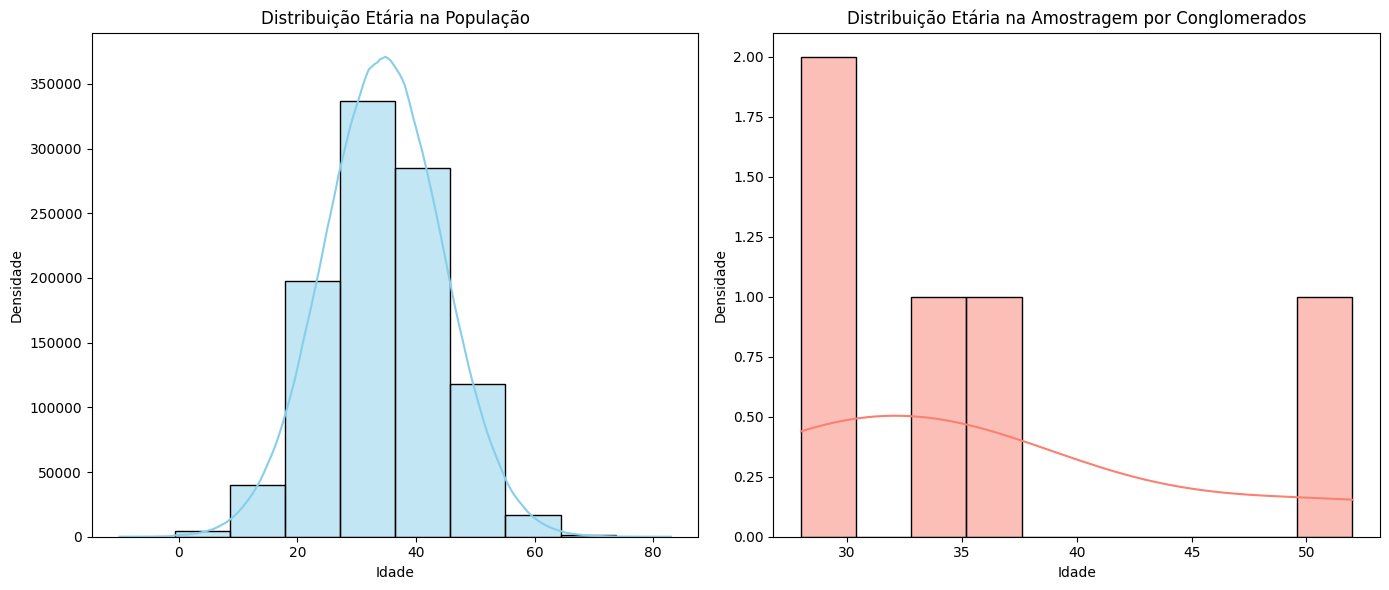

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criar uma figura com dois subgráficos
plt.figure(figsize=(14, 6))

# Primeiro gráfico: Distribuição etária na população
plt.subplot(1, 2, 1)  # (linhas, colunas, índice do gráfico)
sns.histplot(population['Age'], bins=10, kde=True, color='skyblue')
plt.title('Distribuição Etária na População')
plt.xlabel('Idade')
plt.ylabel('Densidade')

# Segundo gráfico: Distribuição etária na amostra
plt.subplot(1, 2, 2)  # (linhas, colunas, índice do gráfico)
sns.histplot(cluster_sample['Age'], bins=10, kde=True, color='salmon')
plt.title('Distribuição Etária na Amostragem por Conglomerados')
plt.xlabel('Idade')
plt.ylabel('Densidade')

plt.tight_layout()
plt.show()

##**Amostragem por Cotas**

A amostragem por cotas é uma técnica de amostragem não probabilística na qual a população é dividida em grupos, chamados de “cotas”, com base em certas características de interesse. Posteriormente, indivíduos são selecionados de cada cota até que um número predeterminado por cota seja alcançado. Este método é utilizado para garantir que a amostra reflita as proporções especificadas das características de interesse presentes na população, mas não garante a aleatoriedade na seleção dos indivíduos.

As cotas são subdivisões da população baseadas em características demográficas ou socioeconômicas específicas, como idade, gênero, nível de escolaridade, renda, etc. Essas cotas são selecionadas para refletir as proporções desejadas de cada característica dentro da população. Após definir as cotas, indivíduos são selecionados de forma não aleatória de cada cota até que o número predeterminado de indivíduos por cota seja alcançado. A seleção dos indivíduos pode ser feita de várias maneiras, por exemplo, usando listas de contato, entrevistas de rua ou chamadas telefônicas. Uma vez que os indivíduos são selecionados de cada cota, eles são combinados para formar a amostra geral. Como os indivíduos foram selecionados de cada cota para garantir que a amostra reflita as proporções desejadas das características de interesse, espera-se que a amostra seja representativa da população geral.

A amostragem por cotas é frequentemente usada quando não é possível utilizar técnicas de amostragem probabilística, como a amostragem aleatória simples, e quando é necessário garantir que a amostra reflita certas características da população. No entanto, é importante observar que a amostragem por cotas pode introduzir viés se as cotas não forem cuidadosamente selecionadas ou se a seleção de indivíduos dentro de cada cota não for aleatória. Portanto, é crucial prestar atenção ao design e à implementação da amostragem por cotas para garantir a representatividade e a confiabilidade da amostra resultante.

**Critério E**

In [ ]:
import pandas as pd

def quota_sampling_fixed(population, quotas):
    """
    Realiza a amostragem por cotas com quantidade fixa controlada.

    quotas (dict): {coluna: (valor_esperado, quantidade_desejada)}
    Exemplo: {'Gender': ('Male', 50), 'Age': (30, 20)}
    """
    sample = pd.DataFrame()

    for attribute, (value, target_amount) in quotas.items():
        # Filtra a população pelo atributo e valor
        subset = population[population[attribute] == value]

        # Verifica se há elementos suficientes na população para suprir a cota
        if len(subset) < target_amount:
            print(f"Aviso: O estrato {attribute}={value} possui apenas {len(subset)} elementos. Retornando todos disponíveis.")
            stratum_sample = subset
        else:
            # Seleciona a quantidade exata controlada
            stratum_sample = subset.sample(n=target_amount, random_state=42)

        sample = pd.concat([sample, stratum_sample])

    # Remove possíveis duplicatas caso um indivíduo atenda a mais de um critério isolado
    return sample.drop_duplicates()

# Exemplo de uso: Quero 15 homens e 10 pessoas de 30 anos
selected_quotas = {'Gender': ('Male', 15), 'Age': (30, 10)}
quota_sample = quota_sampling_fixed(population, selected_quotas)


**Critério OU**

In [ ]:
import pandas as pd

def quota_sampling_combined(population, quotas, n):
    """
    Realiza a amostragem filtrando por todas as cotas combinadas
    e controla o tamanho final da amostra para exatamente 'n'.
    """
    # Começa com a população inteira e vai aplicando os filtros das cotas
    subset = population.copy()

    for attribute, value in quotas.items():
        subset = subset[subset[attribute] == value]

    # Verifica se o subconjunto combinado tem dados suficientes
    if len(subset) < n:
        print(f"Erro: Apenas {len(subset)} indivíduos atendem a todas as cotas simultaneamente. Não é possível extrair {n}.")
        return subset

    # Retorna exatamente a quantidade 'n' controlada
    return subset.sample(n=n, random_state=42)

# Exemplo de uso: Quero uma amostra de tamanho 20 que sejam Homens E tenham 30 anos
selected_quotas = {'Gender': 'Male', 'Age': 30}
quota_sample = quota_sampling_combined(population, selected_quotas, n=20)


**Explicação Detalhada**

**Função quota_sampling:**

    • Parâmetros:
        ◦ population: O DataFrame que contém todos os indivíduos da população.
        ◦ quotas: Um dicionário onde as chaves são os atributos (colunas) e os valores são os critérios específicos para cada cota.
        ◦ Exemplo de dicionário: {'Gender': 'Male', 'Age': 30}

    • Processo:
        ◦ sample = pd.DataFrame(): Inicializa um DataFrame vazio para armazenar os registros selecionados.
        ◦ for attribute, value in quotas.items(): Itera individualmente sobre cada par de atributo e valor definido no dicionário.
        ◦ subset = population[population[attribute] == value]: Filtra a população para isolar apenas os indivíduos que atendem ao critério da cota atual.
        ◦ sample = pd.concat([sample, subset.sample(frac=0.5)]): Seleciona aleatoriamente 50% dos casos encontrados para a cota atual e os acumula no DataFrame final de amostras.

    • Retorno:
        ◦ sample: O DataFrame final contendo a união dos indivíduos selecionados em cada uma das cotas aplicadas.

**Exemplo de Uso:**

    • selected_quotas = {'Gender': 'Male', 'Age': 30}: Define os critérios para extrair de forma independente uma cota de indivíduos do gênero masculino e outra cota de indivíduos com 30 anos de idade.
    • quota_sample = quota_sampling(population, selected_quotas): Executa a função passando o banco de dados e os critérios estabelecidos.
    • print("\nAmostragem por Cotas:"): Imprime o cabeçalho de identificação no console.
    • print(quota_sample): Exibe o DataFrame resultante com os indivíduos selecionados para as cotas.





**Verificando os parâmetros estatísticos descritivos da amostra**

In [ ]:
population.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,1000000.0,500000.500000,288675.278933,1.0,250000.75,500000.5,750000.25,1000000.0
Age,1000000.0,34.503669,5.009829,9.0,31.00,35.0,38.00,57.0
Income,1000000.0,15005.921794,5772.281589,5000.0,10008.00,15014.0,20000.00,24999.0


In [ ]:
quota_sample.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,268425.0,499539.624595,288580.180563,27.0,249497.0,499929.0,749396.0,999998.0
Age,268425.0,34.206378,9.691858,-16.0,28.0,34.0,41.0,79.0
Income,268425.0,14995.133356,5777.457959,5000.0,9994.0,14987.0,20005.0,24999.0


**Visualizando os histogramas juntos**

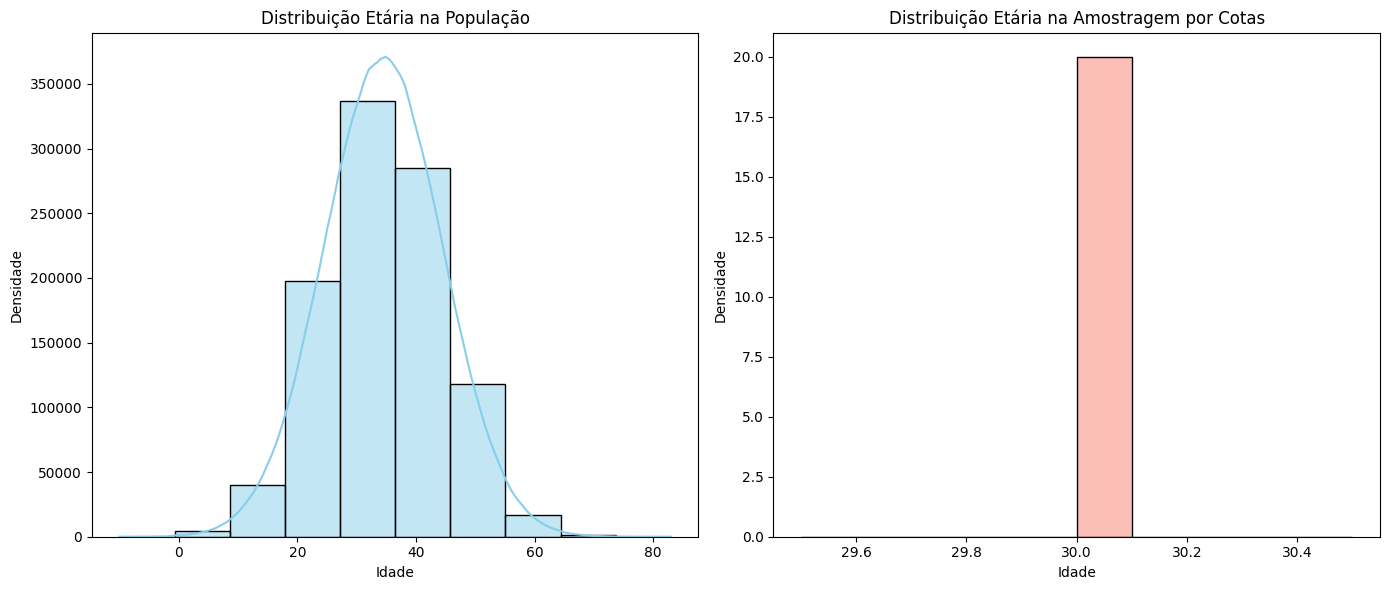

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criar uma figura com dois subgráficos
plt.figure(figsize=(14, 6))

# Primeiro gráfico: Distribuição etária na população
plt.subplot(1, 2, 1)  # (linhas, colunas, índice do gráfico)
sns.histplot(population['Age'], bins=10, kde=True, color='skyblue')
plt.title('Distribuição Etária na População')
plt.xlabel('Idade')
plt.ylabel('Densidade')

# Segundo gráfico: Distribuição etária na amostra
plt.subplot(1, 2, 2)  # (linhas, colunas, índice do gráfico)
sns.histplot(quota_sample['Age'], bins=10, kde=True, color='salmon')
plt.title('Distribuição Etária na Amostragem por Cotas')
plt.xlabel('Idade')
plt.ylabel('Densidade')

plt.tight_layout()
plt.show()